# MODEL TRAINING

In [1]:
# ============================================
# FINAL MODEL TRAINING - REGRESSION
# y_train and y_test are log(price_avg)
# =============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.inspection import partial_dependence
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

with open ('../data/processed/best_features.txt','r') as f:
    best_features=[line.strip() for line in f]

In [2]:
X_train=pd.read_csv('../data/processed/X_train_df.csv')
y_train=pd.read_csv('../data/processed/y_train_df.csv').squeeze()
X_test=pd.read_csv('../data/processed/X_test_df.csv')
y_test=pd.read_csv('../data/processed/y_test_df.csv').squeeze()

In [3]:
X_train_feat=X_train[best_features]
X_test_feat=X_test[best_features]

## Baseline Model

In [20]:
# ============================================
# Baseline Models for Price Prediction
# ============================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# 假设已经加载了 X_train, X_test, y_train, y_test
# y_train 和 y_test 是 log 变换后的价格，需要转换回原始价格进行 MAE 评估
y_train_orig = np.exp(y_train)
y_test_orig = np.exp(y_test)

print("=" * 60)
print("BASELINE EVALUATION (on original price scale, 10k RMB)")
print("=" * 60)

# ============================================
# Baseline 1: Mean Prediction (Dummy Regressor)
# ============================================
dummy_mean = DummyRegressor(strategy='mean')
dummy_mean.fit(X_train_feat, y_train)
y_pred_log_mean = dummy_mean.predict(X_test_feat)
y_pred_mean_orig = np.exp(y_pred_log_mean)

mae_mean = mean_absolute_error(y_test_orig, y_pred_mean_orig)
r2_mean = r2_score(y_test_orig, y_pred_mean_orig)

print(f"\n[1] Mean Prediction (DummyRegressor)")
print(f"    Test MAE: {mae_mean:.2f} (10k RMB)")
print(f"    Test R² : {r2_mean:.4f}")

# ============================================
# Baseline 2: Simple Linear Regression (只用 wheel_base)
# ============================================
# 确保 wheel_base 在 X_train 和 X_test 中不存在 NaN
X_train_wb = X_train[['wheel_base']].copy()
X_test_wb = X_test[['wheel_base']].copy()

# 处理可能的缺失值（如果存在）
X_train_wb = X_train_wb.fillna(X_train_wb.median())
X_test_wb = X_test_wb.fillna(X_train_wb.median())  # 用训练集的中位数填测试集

lr_simple = LinearRegression()
lr_simple.fit(X_train_wb, y_train)
y_pred_log_lr = lr_simple.predict(X_test_wb)
y_pred_lr_orig = np.exp(y_pred_log_lr)

mae_lr = mean_absolute_error(y_test_orig, y_pred_lr_orig)
r2_lr = r2_score(y_test_orig, y_pred_lr_orig)

print(f"\n[2] Simple Linear Regression (only wheel_base)")
print(f"    Coefficient: {lr_simple.coef_[0]:.4f} (per unit)")
print(f"    Intercept: {lr_simple.intercept_:.4f}")
print(f"    Test MAE: {mae_lr:.2f} (10k RMB)")
print(f"    Test R² : {r2_lr:.4f}")

# ============================================
# Baseline 3: K-Nearest Neighbors Regression
# ============================================
# KNN 对特征尺度敏感，先用 StandardScaler 标准化所有特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 尝试不同 K 值，选择最佳（k=3, 5, 7 常见）
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')  # 'distance' 距离越近权重越高
knn.fit(X_train_scaled, y_train)
y_pred_log_knn = knn.predict(X_test_scaled)
y_pred_knn_orig = np.exp(y_pred_log_knn)

mae_knn = mean_absolute_error(y_test_orig, y_pred_knn_orig)
r2_knn = r2_score(y_test_orig, y_pred_knn_orig)

print(f"\n[3] K-Nearest Neighbors Regression (k=5, distance weight)")
print(f"    Test MAE: {mae_knn:.2f} (10k RMB)")
print(f"    Test R² : {r2_knn:.4f}")

# ============================================
# Summary Table
# ============================================
summary = pd.DataFrame({
    'Baseline': ['Mean Prediction', 'Linear Regression (wheel_base)', 'KNN (k=5)'],
    'MAE (10k RMB)': [mae_mean, mae_lr, mae_knn],
    'R²': [r2_mean, r2_lr, r2_knn]
})

print("\n" + "=" * 60)
print("SUMMARY OF BASELINES")
print("=" * 60)
print(summary.to_string(index=False))

# 找出最佳 MAE
best_idx = summary['MAE (10k RMB)'].idxmin()
print(f"\n✅ Best MAE: {summary.loc[best_idx, 'Baseline']} with {summary.loc[best_idx, 'MAE (10k RMB)']:.2f}")

BASELINE EVALUATION (on original price scale, 10k RMB)

[1] Mean Prediction (DummyRegressor)
    Test MAE: 13.63 (10k RMB)
    Test R² : -0.0566

[2] Simple Linear Regression (only wheel_base)
    Coefficient: 0.0022 (per unit)
    Intercept: -3.1902
    Test MAE: 9.50 (10k RMB)
    Test R² : 0.3063

[3] K-Nearest Neighbors Regression (k=5, distance weight)
    Test MAE: 7.00 (10k RMB)
    Test R² : 0.3577

SUMMARY OF BASELINES
                      Baseline  MAE (10k RMB)        R²
               Mean Prediction      13.632447 -0.056637
Linear Regression (wheel_base)       9.495084  0.306329
                     KNN (k=5)       7.003092  0.357698

✅ Best MAE: KNN (k=5) with 7.00


## KNN Model

### Classification

In [33]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 定义价格档次（万元）
bins = [0, 8, 15, 25, 35, 50, 200] 
labels = ['<8w', '8-15w', '15-25w', '25-35w', '35-50w', '>50w']

# 将目标值转换为分类标签
y_train_class = pd.cut(np.exp(y_train), bins=bins, labels=labels)
y_test_class = pd.cut(np.exp(y_test), bins=bins, labels=labels)

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)

# 训练 KNN 分类器
knn_clf = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_clf.fit(X_train_scaled, y_train_class)

# 预测
y_pred_class = knn_clf.predict(X_test_scaled)

# 评估
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

Accuracy: 0.6122

Classification Report:
              precision    recall  f1-score   support

      15-25w       0.72      0.76      0.74        17
      25-35w       0.44      0.44      0.44         9
      35-50w       0.38      0.43      0.40         7
       8-15w       0.64      0.78      0.70         9
         <8w       1.00      0.75      0.86         4
        >50w       0.00      0.00      0.00         3

    accuracy                           0.61        49
   macro avg       0.53      0.53      0.52        49
weighted avg       0.58      0.61      0.60        49



### Regression

In [36]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)

# Train KNN regressor
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

# Predict and convert back to original price
y_pred_log = knn.predict(X_test_scaled)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

# Overall score
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
print(f"\nTest R² (original scale): {r2:.4f}")
print(f"Test MAE (original scale): {mae:.2f} (10k RMB)")

# Define price brackets (same as before)
bins = [0, 8, 15, 25, 35, 50, 200] 
labels = ['<8w', '8-15w', '15-25w', '25-35w', '35-50w', '>50w']
# Categorize true prices into brackets
price_bins = pd.cut(y_true, bins=bins, labels=labels)

# Segment-wise MAE
print("\nSegment-wise MAE (10k RMB):")
for label in labels:
    mask = price_bins == label
    if mask.sum() > 0:
        mae = mean_absolute_error(y_true[mask], y_pred[mask])
        print(f"  {label:10} (n={mask.sum():3d}) : {mae:.2f}")


Test R² (original scale): 0.3850
Test MAE (original scale): 7.42 (10k RMB)

Segment-wise MAE (10k RMB):
  <8w        (n=  4) : 1.03
  8-15w      (n=  9) : 2.34
  15-25w     (n= 17) : 2.93
  25-35w     (n=  9) : 4.79
  35-50w     (n=  7) : 9.62
  >50w       (n=  3) : 59.43


## Randomforest Model

### Regression

#### Apply on all features

In [4]:
# ------------------------------
# Grid search for best parameters (all features)
# ------------------------------
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best CV R²: 0.8421909757784064


#### Apply on best features

In [37]:
# ------------------------------
# Grid search for best parameters(best features)
# ------------------------------
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf = RandomForestRegressor(random_state=42,criterion="absolute_error")

grid_search_feat = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_feat.fit(X_train_feat, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best CV R²: 0.8421909757784064


#### Evaluate on test data

In [38]:
# ------------------------------
#  Evaluate on test set (original price scale)
# ------------------------------
best_rf = grid_search_feat.best_estimator_
y_pred_log = best_rf.predict(X_test_feat)

# Convert back to original price (10k RMB)
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred_log)

r2 = r2_score(y_test_orig, y_pred_orig)
mae = mean_absolute_error(y_test_orig, y_pred_orig)

print(f"\nTest R² (original scale): {r2:.4f}")
print(f"Test MAE (original scale): {mae:.2f} (10k RMB)")


Test R² (original scale): 0.4037
Test MAE (original scale): 7.39 (10k RMB)


#### Evaluation by Price Brackets


=== Segment-wise MAE (10k RMB) ===
<8w          : 1.07
8-15w        : 2.98
15-25w       : 2.24
25-35w       : 7.44
35-50w       : 8.57
>50w         : 55.42


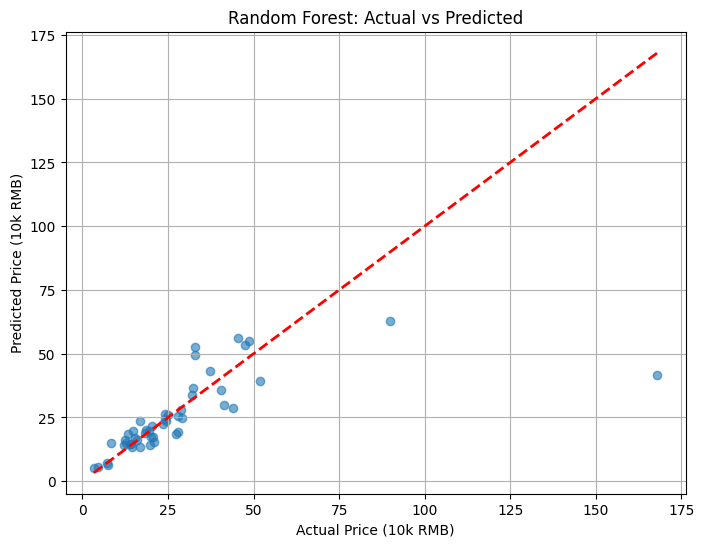

In [39]:
# ------------------------------
# Segment-wise evaluation by price brackets
# ------------------------------
# Define price brackets in original 10k RMB
bins = [0, 8, 15, 25, 35, 50, 200] 
labels = ['<8w', '8-15w', '15-25w', '25-35w', '35-50w', '>50w']

# Create price bracket for each test sample
price_bracket = pd.cut(y_test_orig, bins=bins, labels=labels)

# Calculate MAE per bracket
segment_mae = pd.Series(y_test_orig - y_pred_orig).abs().groupby(price_bracket).mean()

print("\n=== Segment-wise MAE (10k RMB) ===")
for bracket, mae_val in segment_mae.items():
    print(f"{bracket:12} : {mae_val:.2f}")

# ------------------------------
#  Optional: Plot actual vs predicted
# ------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()], 
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price (10k RMB)')
plt.ylabel('Predicted Price (10k RMB)')
plt.title('Random Forest: Actual vs Predicted')
plt.grid(True)
plt.show()

### Classification

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#  Convert continuous price to categories
bins = [0, 8, 15, 25, 35, 50, 200]          # 10k RMB
labels = ['budget', 'entry', 'mid','upper mid', 'Premium', 'Luxury']

y_train_class = pd.cut(np.exp(y_train), bins=bins, labels=labels)
y_test_class = pd.cut(np.exp(y_test), bins=bins, labels=labels)

#  Train classifier
clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
clf.fit(X_train_feat, y_train_class)

#  Evaluate
y_pred_class = clf.predict(X_test_feat)
accuracy = accuracy_score(y_test_class, y_pred_class)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

Accuracy: 0.6327

Classification Report:
              precision    recall  f1-score   support

      Luxury       0.50      0.33      0.40         3
     Premium       0.29      0.29      0.29         7
      budget       1.00      0.75      0.86         4
       entry       0.83      0.56      0.67         9
         mid       0.65      1.00      0.79        17
   upper mid       0.60      0.33      0.43         9

    accuracy                           0.63        49
   macro avg       0.65      0.54      0.57        49
weighted avg       0.64      0.63      0.61        49



In [18]:
y_train_class.value_counts()

price_log
mid          72
upper mid    41
entry        32
Premium      23
Luxury       13
budget       12
Name: count, dtype: int64